Accuracy: 0.9555555555555556


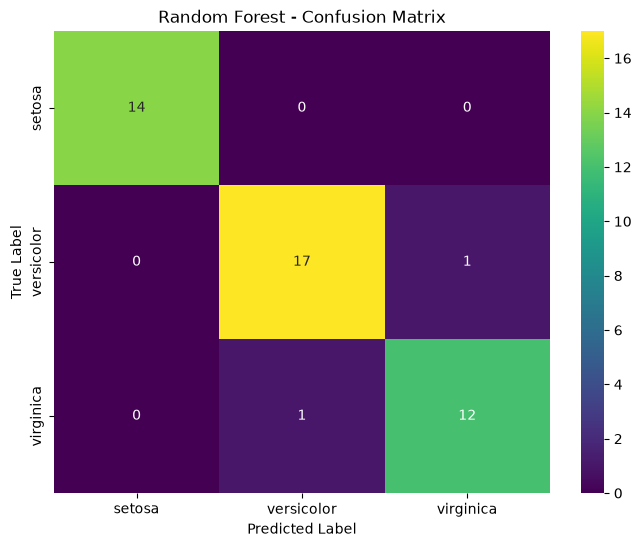

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix


# Load Iris dataset
iris = load_iris()

data = pd.DataFrame(
    data=iris.data,
    columns=iris.feature_names
)

data['Species'] = iris.target


# Separate features and target
X = data.drop('Species', axis=1)
y = data['Species']


# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=1
)


# Create Random Forest model
model = RandomForestClassifier(
    n_estimators=100,
    random_state=1
)


# Train model
model.fit(X_train, y_train)


# Prediction
y_pred = model.predict(X_test)


# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)


# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(
    conf_matrix,
    annot=True,
    fmt='d',
    cmap='viridis',
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Random Forest - Confusion Matrix')

plt.show()